# RAG 파이프라인 (Retrieval-Augmented Generation)

세 가지 공정 지식 소스를 벡터 DB에 저장하고, EXAONE LLM으로 질의응답을 수행하는 파이프라인입니다.

**파이프라인 순서:**
1. 문서 로드 (논문 rule JSON + OPLS 공정 JSON + SHAP 분석 Markdown)
2. 청크 분할 → 임베딩 (multilingual-e5-large-instruct) → Chroma DB 저장
3. LLM 로드 (EXAONE-3.5-7.8B-Instruct, 4bit 양자화)
4. RAG Chain 구성 및 질의응답

**필요 파일:**
- `../data/rag_data_all.json` — 논문 기반 공정 rule
- `../data/opls_process_knowledge.json` — 현업 OPLS 공정 조치 정보
- `../data/shap_analysis_for_rag.md` — SHAP 기반 모델 해석 정보

## 0. 환경 설정

In [1]:
import glob, os, re

files = glob.glob(os.path.expanduser(
    "~/.cache/huggingface/modules/transformers_modules/**/*.py"
), recursive=True)
target = [f for f in files if "modeling_exaone" in f]

for path in target:
    txt = open(path).read()
    # 망가진 create_causal_mask 호출 전체를 올바른 버전으로 교체
    patched = re.sub(
        r'causal_mask = create_causal_mask\(.*?\)',
        (
            "causal_mask = create_causal_mask(\n"
            "            config=self.config,\n"
            "            inputs_embeds=inputs_embeds,\n"
            "            attention_mask=attention_mask,\n"
            "            past_key_values=past_key_values,\n"
            "            position_ids=position_ids,\n"
            "        )"
        ),
        txt,
        flags=re.DOTALL
    )
    if patched != txt:
        open(path, "w").write(patched)
        print(f"패치 완료: {path}")
    else:
        print(f"변경 없음: {path}")


변경 없음: /root/.cache/huggingface/modules/transformers_modules/LGAI_hyphen_EXAONE/EXAONE_hyphen_3_dot_5_hyphen_7_dot_8B_hyphen_Instruct/553ea250b9a5317231459279d5847d6cf955b9aa/modeling_exaone.py


In [2]:
#1. Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

#2. Github에서 코드 가져오기
!git clone https://github.com/heyitsmialee/PRAGma.git
%cd PRAGma

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'PRAGma' already exists and is not an empty directory.
/content/PRAGma


In [3]:
import subprocess, sys, os

PACKAGES = [
    "langchain", "langchain-core", "langchain-community",
    "langchain-text-splitters", "langchain-huggingface",
    "langchain-chroma", "langchain-google-genai",
    "sentence-transformers", "ragas>=0.2.0", "datasets",
    "rank_bm25",
    "langchain-google-vertexai",
]

print("패키지 설치 중...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U"] + PACKAGES, check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers>=4.52.0", "accelerate", "bitsandbytes", "torch"], check=True)
print("설치 완료.")

# 설치 후 import 확인 — 실패 시 자동 런타임 재시작
try:
    import importlib
    importlib.import_module("langchain_huggingface")
    print("패키지 정상 — 재시작 불필요, 다음 셀로 진행합니다.")
except Exception as e:
    print(f"런타임 재시작 필요 ({e})")
    print("재시작 후 자동으로 '모두 실행'을 다시 누르거나 Ctrl+F9를 눌러주세요.")
    os.kill(os.getpid(), 9)

패키지 설치 중...
설치 완료.
패키지 정상 — 재시작 불필요, 다음 셀로 진행합니다.


In [4]:
# API 키 / 토큰 설정
# GitHub 업로드 전 마스킹 필수

HF_TOKEN   = "YOUR_HF_TOKEN"
GEMINI_KEY = "YOUR_GEMINI_API_KEY"

In [5]:
# Google Gemini API 키 설정 (RAGAS judge 모델용)
import os
os.environ["GOOGLE_API_KEY"] = GEMINI_KEY

## 1. 문서 로드 함수

세 가지 소스를 각각 로드합니다.

- `load_json_as_documents`: JSON 항목 전체를 문자열로 변환하여 `Document` 생성, `type` 메타데이터 부여
- `load_markdown_as_documents`: TextLoader로 Markdown 파일 로드, `type=shap_analysis` 메타데이터 부여

In [6]:
# EXAONE modeling_exaone.py가 구버전 API로 create_causal_mask를 호출하는 문제 패치
import transformers.modeling_utils as _tmu

if hasattr(_tmu, 'create_causal_mask'):
    _orig = _tmu.create_causal_mask
    def _patched(*args, **kwargs):
        kwargs.pop('input_embeds', None)
        return _orig(*args, **kwargs)
    _tmu.create_causal_mask = _patched

In [7]:
import os
import json
from typing import List

import torch

from langchain_core.documents import Document
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langchain_chroma import Chroma

from transformers import BitsAndBytesConfig
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline

from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser


def load_json_as_documents(json_path: str, knowledge_type: str) -> List[Document]:
    documents = []

    if not os.path.exists(json_path):
        print(f"JSON 파일 없음: {json_path}")
        return documents

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for item in data:
        content = json.dumps(item, ensure_ascii=False, indent=2)

        documents.append(
            Document(
                page_content=content,
                metadata={
                    "source": json_path,
                    "type": knowledge_type,
                    "id": item.get("paper_id", item.get("opls_id", ""))
                }
            )
        )

    return documents


def load_markdown_as_documents(md_path: str) -> List[Document]:
    if not os.path.exists(md_path):
        print(f"Markdown 파일 없음: {md_path}")
        return []

    loader = TextLoader(file_path=md_path, encoding="utf-8")
    docs = loader.load()

    for doc in docs:
        doc.metadata["source"] = md_path
        doc.metadata["type"] = "shap_analysis"

    return docs

/tmp/ipykernel_30689/521328349.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


## 2. RAG 파이프라인 설정 함수

- **문서 로드**: `rag_data_all.json` (논문 rule) + `opls_process_knowledge.json` (OPLS 공정) + `shap_analysis_for_rag.md` (SHAP 분석)
- **청크 분할**: `chunk_size=700`, `chunk_overlap=100`
- **임베딩 모델**: `intfloat/multilingual-e5-large-instruct`
- **벡터 DB**: Chroma (`chroma_rag_data` 컬렉션), `rebuild_db=True`면 재구성 / `False`면 기존 DB 재사용
- **LLM**: `LGAI-EXAONE/EXAONE-3.5-7.8B-Instruct` (4bit 양자화)
- **Retriever**: 상위 `k=3` 청크 검색
- **프롬프트**: 핵심 답변 · 관련 공정 변수 · 근거 · 공정 조정 방향 포맷

In [8]:
from huggingface_hub import login
login(token=HF_TOKEN)

# 전역 캐시 초기화 — 이미 로드된 경우 재설정하지 않음 (셀 재실행 시 캐시 보존)
if '_embedding_model' not in globals():
    _embedding_model = None
if '_chat_llm' not in globals():
    _chat_llm = None


def load_models(force_reload=False):
    """임베딩 모델과 LLM을 최초 1회만 로드하고 전역 변수로 캐싱합니다.
    이미 로드된 경우 캐시를 재사용하므로 반복 실행해도 안전합니다.
    force_reload=True 로 호출하면 강제로 재로드합니다.
    """
    global _embedding_model, _chat_llm

    if not torch.cuda.is_available():
        raise RuntimeError(
            "CUDA GPU를 찾을 수 없습니다.\n"
            "Runtime > Change runtime type > Hardware accelerator > GPU 로 변경 후 재실행하세요."
        )

    if _embedding_model is None or force_reload:
        print("임베딩 모델 로드 중...")
        _embedding_model = HuggingFaceEmbeddings(
            model_name="intfloat/multilingual-e5-large-instruct"
        )
        print("임베딩 모델 로드 완료")
    else:
        print("[캐시] 임베딩 모델 재사용")

    if _chat_llm is None or force_reload:
        print("EXAONE LLM 로드 중... (최초 1회, 수십 분 소요)")
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        )
        chat_model = HuggingFacePipeline.from_model_id(
            model_id="LGAI-EXAONE/EXAONE-3.5-7.8B-Instruct",
            task="text-generation",
            pipeline_kwargs={
                "max_new_tokens": 1024,
                "do_sample": False,
                "repetition_penalty": 1.03,
                "max_length": None,
            },
            model_kwargs={
                "quantization_config": quantization_config,
                "trust_remote_code": True
            }
        )
        _chat_llm = ChatHuggingFace(llm=chat_model)
        print("LLM 로드 완료")
    else:
        print("[캐시] LLM 재사용")

    return _embedding_model, _chat_llm


def build_rag_chain(
    embedding_model,
    llm,
    paper_json_path="/content/drive/MyDrive/Colab Notebooks/PRAGma/rag_data_all.json",
    opls_json_path="/content/PRAGma/data/opls_process_knowledge.json",
    shap_md_path="/content/drive/MyDrive/Colab Notebooks/PRAGma/shap_analysis_for_rag.md",
    db_dir="./chroma_huggingface",
    rebuild_db=True
):
    """로드된 모델을 받아 문서 로드 → Chroma DB → RAG 체인을 구성합니다.
    모델 재로드 없이 DB·프롬프트를 바꿀 때 이 함수만 다시 호출하세요.
    Returns: (rag_chain, retriever, split_docs)
    """
    print("1. 문서 로드 중...")
    document_list = []
    document_list.extend(load_json_as_documents(paper_json_path, "paper_rule"))
    document_list.extend(load_json_as_documents(opls_json_path, "opls_process_rule"))
    document_list.extend(load_markdown_as_documents(shap_md_path))

    if not document_list:
        print("로드된 문서가 없습니다.")
        return None, None, None

    print(f"로드된 문서 수: {len(document_list)}")

    text_splitter = RecursiveCharacterTextSplitter(chunk_size=700, chunk_overlap=100)
    split_docs = text_splitter.split_documents(document_list)
    print(f"분할된 Chunk 수: {len(split_docs)}")

    print("2. Chroma DB 설정 중...")
    if rebuild_db:
        database = Chroma.from_documents(
            documents=split_docs,
            embedding=embedding_model,
            collection_name="chroma_rag_data",
            persist_directory=db_dir
        )
    else:
        database = Chroma(
            collection_name="chroma_rag_data",
            embedding_function=embedding_model,
            persist_directory=db_dir
        )

    retriever = database.as_retriever(search_kwargs={"k": 3})

    template = """
다음 문맥을 참고하여 질문에 답변해 주세요.

문맥에는 논문 기반 공정 rule, 현업 OPLS 공정 조치 정보,
SHAP 기반 모델 해석 정보가 포함될 수 있습니다.

답변 시 아래 내용을 중심으로 정리해 주세요.
- 질문에 대한 핵심 답변
- 관련 공정 변수
- 모델 또는 문헌 기반 근거
- 필요 시 공정 조정 방향

문맥:
{context}

질문:
{question}

답변:
"""

    prompt = PromptTemplate.from_template(template)

    def format_docs(docs):
        return "\n\n".join(
            f"[source={doc.metadata.get('source', '')}, type={doc.metadata.get('type', '')}]\n{doc.page_content}"
            for doc in docs
        )

    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )

    print("RAG Chain 구성 완료")
    return rag_chain, retriever, split_docs

## 3. 질의응답 함수

`rag_chain.invoke(query)`로 질문 문자열을 직접 전달하고, 답변 문자열을 반환합니다.

In [9]:
def query_rag(rag_chain, query):
    if rag_chain is None:
        print("체인이 구성되지 않았습니다.")
        return None

    print(f"\n[질문]: {query}")

    answer = rag_chain.invoke(query)

    print("[답변]:\n")
    print(answer)

    return answer

## 4. 파이프라인 실행

두 단계로 나눠 실행합니다.

- **Step 1 — 모델 로드**: 최초 1회만 실행. 이미 로드된 경우 `[캐시]` 메시지 출력 후 즉시 반환.
- **Step 2 — RAG 체인 구성**: 모델을 재사용해 빠르게 재구성. 데이터나 파라미터를 바꿀 때 이 셀만 다시 실행하면 됩니다.

In [10]:
# Step 1: 모델 로드 (최초 1회만 실행 — 이미 로드된 경우 캐시 재사용)
embedding_model, llm = load_models()

임베딩 모델 로드 중...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

임베딩 모델 로드 완료
EXAONE LLM 로드 중... (최초 1회, 수십 분 소요)


[transformers] The `check_model_inputs` decorator is deprecated in favor of `merge_with_config_defaults`.


[ERROR] `cache_position` is part of ExaoneModel.forward's signature, but not documented. Make sure to add it to the docstring of the function in /root/.cache/huggingface/modules/transformers_modules/LGAI_hyphen_EXAONE/EXAONE_hyphen_3_dot_5_hyphen_7_dot_8B_hyphen_Instruct/553ea250b9a5317231459279d5847d6cf955b9aa/modeling_exaone.py.
[ERROR] `cache_position` is part of ExaoneForCausalLM.forward's signature, but not documented. Make sure to add it to the docstring of the function in /root/.cache/huggingface/modules/transformers_modules/LGAI_hyphen_EXAONE/EXAONE_hyphen_3_dot_5_hyphen_7_dot_8B_hyphen_Instruct/553ea250b9a5317231459279d5847d6cf955b9aa/modeling_exaone.py.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'max_length', 'repetition_penalty', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


The repository LGAI-EXAONE/EXAONE-3.5-7.8B-Instruct contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/LGAI-EXAONE/EXAONE-3.5-7.8B-Instruct .
 You can inspect the repository content at https://hf.co/LGAI-EXAONE/EXAONE-3.5-7.8B-Instruct.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y
LLM 로드 완료


In [11]:
## 4b. Baseline 비교 체인 구성 함수 정의 (LLM only / BM25 RAG)
from langchain_community.retrievers import BM25Retriever

LLM_ONLY_TEMPLATE = """다음 질문에 답변해 주세요.

질문:
{question}

답변:
"""

BM25_RAG_TEMPLATE = """다음 문맥을 참고하여 질문에 답변해 주세요.

문맥:
{context}

질문:
{question}

답변:
"""

def _fmt(docs):
    return "\n\n".join(
        f"[source={d.metadata.get('source','')}, type={d.metadata.get('type','')}]\n{d.page_content}"
        for d in docs
    )

def build_llm_only_chain(llm):
    prompt = PromptTemplate.from_template(LLM_ONLY_TEMPLATE)
    return prompt | llm | StrOutputParser()

def build_bm25_chain(llm, docs):
    bm25_ret = BM25Retriever.from_documents(docs)
    bm25_ret.k = 3
    prompt = PromptTemplate.from_template(BM25_RAG_TEMPLATE)
    chain = (
        {"context": bm25_ret | _fmt, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )
    return chain, bm25_ret

# 실제 체인 구성은 split_docs가 만들어지는 Step 2(다음 셀) 이후에 실행됩니다.
print("Baseline 체인 함수 정의 완료")

Baseline 체인 함수 정의 완료


In [12]:
# Step 2: RAG 체인 구성 (모델 재로드 없이 빠르게 재구성 가능)
# 데이터나 파라미터를 바꿀 때 이 셀만 다시 실행하면 됩니다.
rag_chain, retriever, split_docs = build_rag_chain(
    embedding_model=embedding_model,
    llm=llm,
    paper_json_path="/content/drive/MyDrive/Colab Notebooks/PRAGma/rag_data_all.json",
    opls_json_path="/content/drive/MyDrive/Colab Notebooks/PRAGma/opls_process_knowledge.json",
    shap_md_path="/content/drive/MyDrive/Colab Notebooks/PRAGma/shap_analysis_for_rag.md",
    db_dir="./chroma_huggingface",
    rebuild_db=True
)

1. 문서 로드 중...
로드된 문서 수: 11
분할된 Chunk 수: 45
2. Chroma DB 설정 중...
RAG Chain 구성 완료


In [13]:
# Step 2b: Baseline 체인 구성 (split_docs 생성 이후 실행)
llm_only_chain       = build_llm_only_chain(llm)
bm25_chain, bm25_ret = build_bm25_chain(llm, split_docs)
print("Baseline 체인 구성 완료  (LLM only / BM25 RAG)")

Baseline 체인 구성 완료  (LLM only / BM25 RAG)


## 5. 질의응답 테스트

In [14]:
import sys, inspect

for mod_name, mod in list(sys.modules.items()):
    if 'exaone' in mod_name.lower() and hasattr(mod, 'create_causal_mask'):
        _orig = mod.create_causal_mask
        _valid = set(inspect.signature(_orig).parameters.keys())
        print(f"패치 대상: {mod_name}")
        print(f"함수가 받는 인자: {_valid}")

        def _make_patched(orig_fn, valid_params):
            def _patched(*args, **kwargs):
                # input_embeds → inputs_embeds 이름만 수정, 필터링 하지 않음
                if 'input_embeds' in kwargs:
                    kwargs['inputs_embeds'] = kwargs.pop('input_embeds')
                return orig_fn(*args, **kwargs)
            return _patched

        mod.create_causal_mask = _make_patched(_orig, _valid)
        print("패치 완료")

패치 대상: transformers_modules.LGAI_hyphen_EXAONE.EXAONE_hyphen_3_dot_5_hyphen_7_dot_8B_hyphen_Instruct.553ea250b9a5317231459279d5847d6cf955b9aa.modeling_exaone
함수가 받는 인자: {'attention_mask', 'block_sequence_ids', 'or_mask_function', 'position_ids', 'inputs_embeds', 'config', 'past_key_values', 'and_mask_function'}
패치 완료


In [15]:
if rag_chain is not None:
    query = "Etching 온도와 비중이 높을 때 어떤 문제가 발생할 수 있고 어떻게 조치해야 하나요?"
    answer = query_rag(rag_chain, query)
else:
    print("RAG 파이프라인 구성 실패. 파일 경로를 확인해주세요.")

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



[질문]: Etching 온도와 비중이 높을 때 어떤 문제가 발생할 수 있고 어떻게 조치해야 하나요?


[transformers] The remote code model you are currently using seems to expect `cache_position`. This arg has been removed from the Transformers library, and will stop being created in `generate` even for remote code models in a future release. Please open a PR on the remote code hub repo to remove any usage of `cache_position`.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[답변]:

[|system|][|endofturn|]
[|user|]
다음 문맥을 참고하여 질문에 답변해 주세요.

문맥에는 논문 기반 공정 rule, 현업 OPLS 공정 조치 정보,
SHAP 기반 모델 해석 정보가 포함될 수 있습니다.

답변 시 아래 내용을 중심으로 정리해 주세요.
- 질문에 대한 핵심 답변
- 관련 공정 변수
- 모델 또는 문헌 기반 근거
- 필요 시 공정 조정 방향

문맥:
[source=/content/drive/MyDrive/Colab Notebooks/PRAGma/opls_process_knowledge.json, type=opls_process_rule]
},
      "risk": "식각 속도 증가 및 과에칭 가능성 증가",
      "confidence": "high",
      "korean_rule_explanation": "Etching 온도가 53도 이상으로 상승하면 식각 속도가 증가하여 선폭 감소 및 과에칭 불량으로 이어질 수 있다."
    }
  ],
  "core_point": "비중계 센서는 구리 슬러지에 취약하므로 주 1회 정기 세척이 필요하며, 데이터가 갑자기 튀는 경우 가장 먼저 센서 세척을 실시해야 한다."
}

[source=/content/drive/MyDrive/Colab Notebooks/PRAGma/opls_process_knowledge.json, type=opls_process_rule]
},
      "risk": "식각 속도 증가 및 과에칭 가능성 증가",
      "confidence": "high",
      "korean_rule_explanation": "Etching 온도가 53도 이상으로 상승하면 식각 속도가 증가하여 선폭 감소 및 과에칭 불량으로 이어질 수 있다."
    }
  ],
  "core_point": "비중계 센서는 구리 슬러지에 취약하므로 주 1회 정기 세척이 필요하며, 데이터가 갑자기 튀는 경우 가장 먼저 센서 세척을 실시해야 한다."
}

[so

## 6. RAG 성능 평가

세 가지 시스템을 비교 평가합니다.

| 시스템 | 설명 |
|---|---|
| **LLM only** | 검색 없이 EXAONE에 직접 질의 (Baseline) |
| **BM25 RAG** | 키워드 기반 검색 + EXAONE |
| **Vector RAG** | 벡터 검색 (현재 시스템) + EXAONE |

- **평가 데이터셋**: 30개 Q&A 쌍 (도메인 전문가 작성)
- **Judge 모델**: Google Gemini (자기 평가 편향 제거)
- **평가 지표**: Faithfulness · Answer Relevancy · Context Precision · Context Recall

In [16]:
QA_DATASET = [
    # ── Etching 온도 ──────────────────────────────────────────
    {
        "question": "Etching 온도가 정상 범위보다 높을 때 발생하는 불량 유형과 조치 방법은 무엇인가요?",
        "ground_truth": (
            "Etching 온도가 높으면 부식 속도가 과도해져 선폭 감소, 과부식(over-etching), 언더컷 불량이 발생합니다. "
            "조치는 온도를 정상 범위로 낮추거나 컨베이어 속도를 높여 접촉 시간을 줄이는 것입니다."
        ),
    },
    {
        "question": "Etching 온도가 정상 범위보다 낮을 때 어떤 문제가 발생하며 어떻게 대응해야 하나요?",
        "ground_truth": (
            "온도가 낮으면 부식 속도가 부족해 잔동(under-etching)이 발생하고 단락 불량으로 이어질 수 있습니다. "
            "히터 점검 후 온도를 정상 범위로 높이거나 컨베이어 속도를 낮춰 접촉 시간을 늘려야 합니다."
        ),
    },
    {
        "question": "Etching 온도 변동이 수율에 미치는 영향을 SHAP 분석 결과와 연결해 설명해 주세요.",
        "ground_truth": (
            "SHAP 분석 결과 Etching 온도는 수율에 가장 큰 영향을 미치는 변수 중 하나입니다. "
            "정상 범위를 벗어날수록 SHAP 기여값이 음수 방향으로 커져 수율 저하와 강한 상관관계를 보입니다. "
            "온도 안정화가 수율 개선의 최우선 과제입니다."
        ),
    },
    # ── Etching 비중 ──────────────────────────────────────────
    {
        "question": "Etching 비중이 높을 때 발생하는 문제와 조치 방법은 무엇인가요?",
        "ground_truth": (
            "비중이 높으면 구리 이온이 과포화 상태가 되어 부식 효율이 떨어지고 불균일 에칭이 발생합니다. "
            "순수(DIW)를 보충하거나 산화제를 추가해 비중을 정상 범위로 낮춰야 합니다."
        ),
    },
    {
        "question": "Etching 비중이 낮을 때 나타나는 현상과 대응 방법을 설명해 주세요.",
        "ground_truth": (
            "비중이 낮으면 구리 이온 농도가 부족해 에칭 속도가 저하되고 잔동 불량이 발생합니다. "
            "농축 약액을 보충해 비중을 정상 범위로 높이고 에칭액 교체 주기를 단축해야 합니다."
        ),
    },
    {
        "question": "Etching 온도와 비중이 동시에 높을 때 어떤 문제가 발생하고 어떻게 조치해야 하나요?",
        "ground_truth": (
            "온도와 비중이 동시에 높으면 과부식 위험이 복합적으로 증가합니다. "
            "즉시 컨베이어 속도를 높여 접촉 시간을 줄이고, 순수 보충으로 비중을 낮추며 온도를 냉각해야 합니다. "
            "두 변수를 개별 조정하되 상호 영향을 확인하며 단계적으로 정상화합니다."
        ),
    },
    # ── 컨베이어 속도 ─────────────────────────────────────────
    {
        "question": "Etching 컨베이어 속도가 너무 빠를 때 발생하는 영향과 조치는 무엇인가요?",
        "ground_truth": (
            "컨베이어 속도가 빠르면 에칭 접촉 시간이 짧아져 잔동(under-etching) 및 단락 불량이 발생합니다. "
            "속도를 정상 범위로 낮추고 에칭 온도와 비중도 함께 확인해 전체 공정 조건을 맞춰야 합니다."
        ),
    },
    {
        "question": "Etching 컨베이어 속도가 너무 느릴 때의 영향과 대응 방안을 설명해 주세요.",
        "ground_truth": (
            "속도가 느리면 과부식, 언더컷, 선폭 감소 불량이 발생합니다. "
            "속도를 정상 범위로 높이거나 에칭액 온도를 낮춰 반응 속도를 보정해야 합니다."
        ),
    },
    {
        "question": "Etching 온도와 컨베이어 속도의 상관관계를 공정 제어 관점에서 설명해 주세요.",
        "ground_truth": (
            "온도가 높을수록 에칭 반응 속도가 빨라지므로 과부식을 방지하려면 컨베이어 속도를 높여야 합니다. "
            "반대로 온도가 낮으면 속도를 줄여 충분한 에칭 시간을 확보합니다. "
            "두 변수는 반비례 관계로 연동 제어하는 것이 최적입니다."
        ),
    },
    # ── 에칭 품질 ─────────────────────────────────────────────
    {
        "question": "Etching 후 선폭이 설계값보다 감소하는 원인과 조치 방법은 무엇인가요?",
        "ground_truth": (
            "선폭 감소는 과부식, 고온, 저속 컨베이어, 과도한 산화제가 원인입니다. "
            "온도·속도·비중을 정상 범위로 조정하고 D/F 노광 조건도 점검해 선폭 편차를 최소화합니다."
        ),
    },
    {
        "question": "Etching 불균일이 발생하는 주요 원인은 무엇인가요?",
        "ground_truth": (
            "노즐 막힘, 펌프 압력 불균일, 에칭액 농도 구배, 컨베이어 진동이 주요 원인입니다. "
            "노즐 세척, 펌프 압력 점검, 에칭액 교반 강화, 컨베이어 수평 조정으로 대응합니다."
        ),
    },
    {
        "question": "언더컷(Undercut) 불량이 발생하는 원인과 방지 방법을 설명해 주세요.",
        "ground_truth": (
            "언더컷은 패턴 측면이 수직 방향 이상으로 과부식되는 현상으로 고온·고산화제·저속이 원인입니다. "
            "에칭 시간 최소화, 온도 하향, 산화제 농도 조정으로 방지하며 D/F 밀착력도 확인해야 합니다."
        ),
    },
    {
        "question": "산화제(H₂O₂) 농도가 낮을 때 Etching 공정에 미치는 영향과 조치는 무엇인가요?",
        "ground_truth": (
            "산화제가 부족하면 Cu²⁺ 재산화가 느려져 에칭 속도가 저하되고 잔동 불량이 증가합니다. "
            "산화제를 보충하고 에칭액의 산화환원전위(ORP)를 모니터링해 적정 범위를 유지합니다."
        ),
    },
    # ── AOI 검사 ──────────────────────────────────────────────
    {
        "question": "AOI 검사에서 이상이 감지되었을 때 우선 점검해야 할 공정 구간은 어디인가요?",
        "ground_truth": (
            "AOI 이상 시 Etching 구간의 온도와 비중을 우선 확인합니다. "
            "이후 D/F 노광·현상 조건, 도금 두께를 점검하며 OPLS 기준값과 현재 공정값 이탈 여부를 판단합니다."
        ),
    },
    {
        "question": "AOI 과검출이 자주 발생하는 원인과 임계값 재설정 방법을 설명해 주세요.",
        "ground_truth": (
            "과검출은 조명 변화, 기판 표면 오염, 임계값 과도 설정이 주요 원인입니다. "
            "조명 교정, 기판 세척 강화, 이력 데이터 기반으로 임계값을 통계적으로 재산정해야 합니다."
        ),
    },
    {
        "question": "AOI 미검출 리스크를 줄이기 위한 검사 파라미터 최적화 방법은 무엇인가요?",
        "ground_truth": (
            "미검출을 줄이려면 민감도를 높이되 과검출과의 균형을 유지해야 합니다. "
            "과거 불량 유형별 이미지를 학습 데이터로 추가하고 ROC 곡선 분석으로 최적 임계값을 설정합니다."
        ),
    },
    {
        "question": "AOI 불량 패턴을 분석해 공정 이상을 추적하는 방법을 설명해 주세요.",
        "ground_truth": (
            "불량 위치, 유형, 발생 시간을 매핑해 특정 공정 구간과의 상관관계를 분석합니다. "
            "클러스터링으로 반복 패턴을 추출하고 OPLS 기준과 비교해 원인 공정을 역추적합니다."
        ),
    },
    # ── SHAP 분석 ─────────────────────────────────────────────
    {
        "question": "SHAP 분석 결과에서 최종검사 수율에 가장 영향력이 높은 공정 변수는 무엇인가요?",
        "ground_truth": (
            "SHAP 분석 결과 Etching 온도, 비중, 컨베이어 속도가 수율에 가장 큰 영향을 미칩니다. "
            "이 변수들이 정상 범위를 벗어날 때 수율 저하와 강한 상관관계가 나타납니다."
        ),
    },
    {
        "question": "SHAP 값이 음수인 공정 변수는 어떤 의미를 가지나요?",
        "ground_truth": (
            "SHAP 값이 음수인 변수는 해당 시점의 변수값이 수율 예측을 낮추는 방향으로 기여한다는 의미입니다. "
            "즉 해당 변수가 정상 범위를 이탈해 불량 발생 가능성을 높이는 상태임을 나타냅니다."
        ),
    },
    {
        "question": "SHAP 분석 결과를 실제 공정 개선에 적용하는 절차를 설명해 주세요.",
        "ground_truth": (
            "SHAP 중요도가 높은 변수를 우선순위로 정해 관리 범위를 강화합니다. "
            "SHAP 음수 기여 구간의 공정 이력을 분석해 이탈 원인을 파악하고 "
            "OPLS 조치 기준에 따라 해당 파라미터의 제어 범위를 조정합니다."
        ),
    },
    {
        "question": "동일 변수의 SHAP 중요도가 시기별로 변화하는 경우 어떻게 해석해야 하나요?",
        "ground_truth": (
            "공정 조건 변경, 설비 노화, 원자재 변화로 인해 변수 중요도가 달라질 수 있습니다. "
            "시계열 SHAP 분석으로 중요도 변화 시점을 특정하고 해당 시점의 설비·재료 이력을 함께 검토해야 합니다."
        ),
    },
    # ── 수율 예측 모델 ────────────────────────────────────────
    {
        "question": "수율 예측 모델을 활용한 공정 이상 조기 감지 방법을 설명해 주세요.",
        "ground_truth": (
            "실시간 공정 데이터를 입력해 예측 수율이 임계값 이하로 떨어지면 경보를 발생시킵니다. "
            "SHAP 값으로 기여 변수를 파악하고 OPLS 기준에 따라 해당 파라미터를 조정합니다."
        ),
    },
    {
        "question": "수율 예측값과 실제 수율이 지속적으로 차이날 때 어떤 조치를 취해야 하나요?",
        "ground_truth": (
            "공정 조건 변화나 설비 드리프트로 인한 데이터 분포 변화(concept drift)를 의심해야 합니다. "
            "최신 데이터로 모델을 재학습하거나 예측 보정 계수를 적용하고 입력 변수 결측·이상값을 점검합니다."
        ),
    },
    {
        "question": "수율 예측 모델 재학습이 필요한 시점을 판단하는 기준은 무엇인가요?",
        "ground_truth": (
            "예측 오차(MAE, RMSE)가 기준치를 초과하거나 잔차 패턴이 체계적으로 편향될 때 재학습이 필요합니다. "
            "공정 조건 대규모 변경, 설비 교체, 원자재 사양 변화 후에도 즉시 재학습을 고려해야 합니다."
        ),
    },
    {
        "question": "수율 개선을 위해 가장 먼저 조정해야 할 공정 변수 선정 방법은 무엇인가요?",
        "ground_truth": (
            "SHAP 중요도가 높고 현재 OPLS 기준을 이탈한 변수를 우선 선정합니다. "
            "조정 비용 대비 수율 향상 효과를 추정해 ROI가 높은 변수부터 순차적으로 개선합니다."
        ),
    },
    # ── 복합 공정 / 종합 ──────────────────────────────────────
    {
        "question": "D/F 노광 조건 이상 시 발생하는 불량 유형과 Etching 공정과의 연관성을 설명해 주세요.",
        "ground_truth": (
            "노광 부족은 잔막 발생으로 에칭 불완전을, 과노광은 선폭 감소를 초래합니다. "
            "D/F 불량은 후속 Etching 공정에서 선폭 편차와 불균일 에칭으로 이어지므로 "
            "두 공정 조건을 연동해 관리해야 합니다."
        ),
    },
    {
        "question": "도금 두께 불균일이 발생하는 원인과 후속 공정에 미치는 영향은 무엇인가요?",
        "ground_truth": (
            "전류 밀도 불균일, 애노드 소모, 전해액 농도 구배가 주요 원인입니다. "
            "두께 불균일은 Etching 시 패턴 손상과 AOI 불량 증가로 이어지므로 "
            "도금 설비 점검과 전해액 보충을 정기적으로 수행해야 합니다."
        ),
    },
    {
        "question": "복합 공정 이상이 동시에 발생할 때 점검 우선순위를 어떻게 결정하나요?",
        "ground_truth": (
            "SHAP 중요도와 OPLS 이탈 정도를 종합해 수율 영향이 큰 변수를 우선 처리합니다. "
            "Etching 온도·비중처럼 즉각 조치 가능한 변수를 먼저 정상화하고 "
            "설비 점검이 필요한 항목은 다음 단계로 진행합니다."
        ),
    },
    {
        "question": "OPLS 공정 기준값을 활용해 실시간 이상을 감지하는 방법을 설명해 주세요.",
        "ground_truth": (
            "실시간 공정값을 OPLS 상·하한 기준과 비교해 이탈 발생 시 즉시 알람을 발생시킵니다. "
            "이탈 이력을 누적 분석해 반복 이탈 구간을 파악하고 예방 조치 기준을 강화합니다."
        ),
    },
    {
        "question": "제조 데이터 기반으로 공정 이상을 사전에 예방하는 전략을 설명해 주세요.",
        "ground_truth": (
            "수율 예측 모델로 이상 징후를 조기에 탐지하고 SHAP 분석으로 원인 변수를 특정합니다. "
            "OPLS 기준 대비 공정값 트렌드를 모니터링해 이탈 전 예방 조치를 취하며 "
            "불량 이력 패턴을 학습해 유사 상황에서 자동 경보와 조치 가이드를 제공합니다."
        ),
    },
    {
        "question": "수율 저하가 발생했을 때 원인을 체계적으로 분석하는 절차를 설명해 주세요.",
        "ground_truth": (
            "1) 수율 저하 발생 시점의 공정 파라미터를 수집합니다. "
            "2) SHAP 분석으로 기여 변수를 확인합니다. "
            "3) OPLS 기준 이탈 항목을 특정합니다. "
            "4) AOI 불량 패턴과 위치를 분석해 특정 공정 구간을 역추적합니다. "
            "5) 해당 구간 설비 점검 후 조치하고 수율 회복을 확인합니다."
        ),
    },
]

print(f"평가 데이터셋: {len(QA_DATASET)}개 Q&A 쌍 준비 완료")

평가 데이터셋: 31개 Q&A 쌍 준비 완료


In [17]:
def collect_eval_data(qa_dataset, retriever, rag_chain):
    """각 질문에 대해 Vector RAG 답변과 검색된 컨텍스트를 수집합니다."""
    eval_records = []
    total = len(qa_dataset)

    for i, item in enumerate(qa_dataset):
        question = item["question"]
        print(f"[{i+1}/{total}] {question[:45]}...")

        docs = retriever.invoke(question)
        contexts = [doc.page_content for doc in docs]
        answer = rag_chain.invoke(question)

        eval_records.append({
            "question": question,
            "answer": answer,
            "contexts": contexts,
            "ground_truth": item["ground_truth"],
        })
        print(f"       답변 생성 완료 (컨텍스트 {len(contexts)}개 검색)")

    print(f"\n수집 완료: {len(eval_records)}개 레코드")
    return eval_records


def collect_baseline_eval(qa_dataset, chains: dict):
    """
    세 시스템(LLM only / BM25 RAG / Vector RAG)의 평가 데이터를 한 번에 수집합니다.
    chains = {
        "llm_only":   llm_only_chain,
        "bm25_rag":   (bm25_chain, bm25_retriever),
        "vector_rag": (rag_chain, retriever),
    }
    """
    records = {name: [] for name in chains}
    total = len(qa_dataset)

    for i, item in enumerate(qa_dataset):
        q  = item["question"]
        gt = item["ground_truth"]
        print(f"[{i+1}/{total}] {q[:40]}...")

        for name, chain_obj in chains.items():
            if name == "llm_only":
                answer   = chain_obj.invoke({"question": q})
                contexts = [""]
            else:
                _chain, _retriever = chain_obj
                docs     = _retriever.invoke(q)
                answer   = _chain.invoke(q)
                contexts = [d.page_content for d in docs]

            records[name].append({
                "question":     q,
                "answer":       answer,
                "contexts":     contexts,
                "ground_truth": gt,
            })

    print("\n전체 수집 완료")
    return records

In [56]:
import sys, os
from types import ModuleType
from typing import List

if 'langchain_community.chat_models.vertexai' not in sys.modules:
    _stub = ModuleType('langchain_community.chat_models.vertexai')
    _stub.ChatVertexAI = type('ChatVertexAI', (), {})
    sys.modules['langchain_community.chat_models.vertexai'] = _stub

if 'langchain_community.llms.vertexai' not in sys.modules:
    _stub2 = ModuleType('langchain_community.llms.vertexai')
    _stub2.VertexAI = type('VertexAI', (), {})
    sys.modules['langchain_community.llms.vertexai'] = _stub2

from sentence_transformers import SentenceTransformer
from langchain_core.embeddings import Embeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from ragas import evaluate
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision, ContextRecall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from datasets import Dataset
import pandas as pd


class STEmbeddings(Embeddings):
    def __init__(self, model_name="paraphrase-multilingual-MiniLM-L12-v2"):
        self.model = model_name          # 문자열 — ragas 텔레메트리용
        self._st = SentenceTransformer(model_name)

    def embed_documents(self, texts):
        return self._st.encode(texts, show_progress_bar=False).tolist()

    def embed_query(self, text):
        return self._st.encode([text], show_progress_bar=False)[0].tolist()


_st_emb = None

def run_ragas_evaluation(eval_records):
    global _st_emb

    judge_llm = ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        google_api_key=os.environ.get("GOOGLE_API_KEY"),
        temperature=0,
    )

    if _st_emb is None:
        print("임베딩 모델 로드 중: paraphrase-multilingual-MiniLM-L12-v2")
        _st_emb = STEmbeddings()

    ragas_llm = LangchainLLMWrapper(judge_llm)
    ragas_emb = LangchainEmbeddingsWrapper(_st_emb)

    metrics = [Faithfulness(), AnswerRelevancy(), ContextPrecision(), ContextRecall()]

    dataset = Dataset.from_dict({
        "question":  [r["question"]     for r in eval_records],
        "answer":    [r["answer"]       for r in eval_records],
        "contexts":  [r["contexts"]     for r in eval_records],
        "reference": [r["ground_truth"] for r in eval_records],
    })

    print("RAGAS 평가 실행 중 (LLM: gemini-2.5-flash / 임베딩: multilingual-MiniLM)...")
    result = evaluate(
        dataset=dataset,
        metrics=metrics,
        llm=ragas_llm,
        embeddings=ragas_emb,
    )
    return result.to_pandas()

print("run_ragas_evaluation 정의 완료")


run_ragas_evaluation 정의 완료


/tmp/ipykernel_30689/1627229693.py:19: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision, ContextRecall
/tmp/ipykernel_30689/1627229693.py:19: DeprecationWarning: Importing AnswerRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AnswerRelevancy
  from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision, ContextRecall
/tmp/ipykernel_30689/1627229693.py:19: DeprecationWarning: Importing ContextPrecision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextPrecision
  from ragas.metrics import Faithfulness, 

In [22]:
# 세 시스템 답변 수집 (30개 × 3 시스템 — 시간이 걸립니다)
baseline_chains = {
    "llm_only":   llm_only_chain,
    "bm25_rag":   (bm25_chain, bm25_ret),
    "vector_rag": (rag_chain, retriever),
}
baseline_records = collect_baseline_eval(QA_DATASET, baseline_chains)

# 기존 단독 평가용 records도 유지
eval_records = baseline_records["vector_rag"]

[1/31] Etching 온도가 정상 범위보다 높을 때 발생하는 불량 유형과 조치 ...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[2/31] Etching 온도가 정상 범위보다 낮을 때 어떤 문제가 발생하며 어떻게...
[3/31] Etching 온도 변동이 수율에 미치는 영향을 SHAP 분석 결과와 연...


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[4/31] Etching 비중이 높을 때 발생하는 문제와 조치 방법은 무엇인가요?...
[5/31] Etching 비중이 낮을 때 나타나는 현상과 대응 방법을 설명해 주세요...
[6/31] Etching 온도와 비중이 동시에 높을 때 어떤 문제가 발생하고 어떻게...
[7/31] Etching 컨베이어 속도가 너무 빠를 때 발생하는 영향과 조치는 무엇...
[8/31] Etching 컨베이어 속도가 너무 느릴 때의 영향과 대응 방안을 설명해...
[9/31] Etching 온도와 컨베이어 속도의 상관관계를 공정 제어 관점에서 설명...
[10/31] Etching 후 선폭이 설계값보다 감소하는 원인과 조치 방법은 무엇인가...
[11/31] Etching 불균일이 발생하는 주요 원인은 무엇인가요?...
[12/31] 언더컷(Undercut) 불량이 발생하는 원인과 방지 방법을 설명해 주세...
[13/31] 산화제(H₂O₂) 농도가 낮을 때 Etching 공정에 미치는 영향과 조...
[14/31] AOI 검사에서 이상이 감지되었을 때 우선 점검해야 할 공정 구간은 어디...
[15/31] AOI 과검출이 자주 발생하는 원인과 임계값 재설정 방법을 설명해 주세요...
[16/31] AOI 미검출 리스크를 줄이기 위한 검사 파라미터 최적화 방법은 무엇인가...
[17/31] AOI 불량 패턴을 분석해 공정 이상을 추적하는 방법을 설명해 주세요....
[18/31] SHAP 분석 결과에서 최종검사 수율에 가장 영향력이 높은 공정 변수는 ...
[19/31] SHAP 값이 음수인 공정 변수는 어떤 의미를 가지나요?...
[20/31] SHAP 분석 결과를 실제 공정 개선에 적용하는 절차를 설명해 주세요....
[21/31] 동일 변수의 SHAP 중요도가 시기별로 변화하는 경우 어떻게 해석해야 하...
[22/31] 수율 예측 모델을 활용한 공정 이상 조기 감지 방법을 설명해 주세요....
[23/31] 수율 예측값과 실제 수율이 지속적으로 차이날 때 어떤 조치를

In [33]:
# baseline_records 저장
import json

RECORDS_SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/PRAGma/baseline_records.json"

with open(RECORDS_SAVE_PATH, "w", encoding="utf-8") as f:
    json.dump(baseline_records, f, ensure_ascii=False, indent=2)

print(f"저장 완료: {RECORDS_SAVE_PATH}")
print(f"시스템: {list(baseline_records.keys())}, 각 {len(baseline_records[list(baseline_records.keys())[0]])}개 Q&A")


저장 완료: /content/drive/MyDrive/Colab Notebooks/PRAGma/baseline_records.json
시스템: ['llm_only', 'bm25_rag', 'vector_rag'], 각 31개 Q&A


In [59]:
# 세 시스템 RAGAS 평가 실행 및 비교표 출력
metric_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
system_results = {}

for sys_name, records in baseline_records.items():
    print(f"\n[{sys_name}] 평가 중 ({len(records)}개)...")
    df = run_ragas_evaluation(records)
    system_results[sys_name] = df
    print(f"  평균: {df[metric_cols].mean().round(3).to_dict()}")

# 비교 요약표
summary_rows = []
for name, df in system_results.items():
    row = df[metric_cols].mean().round(4).to_dict()
    row["system"] = name
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("system")
print("\n===== Baseline 비교 결과 =====")
print(summary_df.to_string())

# cell-22 시각화용 변수 설정
result_df = system_results["vector_rag"]


[llm_only] 평가 중 (31개)...
임베딩 모델 로드 중: paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RAGAS 평가 실행 중 (LLM: gemini-2.5-flash / 임베딩: multilingual-MiniLM)...


/tmp/ipykernel_30689/1627229693.py:53: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_llm = LangchainLLMWrapper(judge_llm)
/tmp/ipykernel_30689/1627229693.py:54: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_emb = LangchainEmbeddingsWrapper(_st_emb)


Evaluating:   0%|          | 0/124 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/124 [00:00<?, ?it/s]

  평균: {'faithfulness': 0.402, 'answer_relevancy': 0.762, 'context_precision': 0.218, 'context_recall': 0.114}

[vector_rag] 평가 중 (31개)...
RAGAS 평가 실행 중 (LLM: gemini-2.5-flash / 임베딩: multilingual-MiniLM)...


/tmp/ipykernel_30689/1627229693.py:53: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_llm = LangchainLLMWrapper(judge_llm)
/tmp/ipykernel_30689/1627229693.py:54: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_emb = LangchainEmbeddingsWrapper(_st_emb)


Evaluating:   0%|          | 0/124 [00:00<?, ?it/s]

  평균: {'faithfulness': 0.46, 'answer_relevancy': 0.895, 'context_precision': 0.258, 'context_recall': 0.016}

===== Baseline 비교 결과 =====
            faithfulness  answer_relevancy  context_precision  context_recall
system                                                                       
llm_only          0.0000            0.8797             0.0000          0.0000
bm25_rag          0.4021            0.7621             0.2177          0.1140
vector_rag        0.4599            0.8947             0.2581          0.0161


In [61]:
# ─── Ablation: 데이터 소스 조합별 답변 수집 ──────────────────────────────
# 4가지 조합 × 10개 질문 = 40회 LLM 호출

_X    = "/disabled"
PAPER = "/content/drive/MyDrive/Colab Notebooks/PRAGma/rag_data_all.json"
OPLS  = "/content/drive/MyDrive/Colab Notebooks/PRAGma/opls_process_knowledge.json"
SHAP  = "/content/drive/MyDrive/Colab Notebooks/PRAGma/shap_analysis_for_rag.md"
ABLATION_CONFIGS = {
    "Paper only":  dict(paper_json_path=PAPER, opls_json_path=_X,   shap_md_path=_X),
    "OPLS only":   dict(paper_json_path=_X,    opls_json_path=OPLS, shap_md_path=_X),
    "SHAP only":   dict(paper_json_path=_X,    opls_json_path=_X,   shap_md_path=SHAP),
    "All (A+B+C)": dict(paper_json_path=PAPER, opls_json_path=OPLS, shap_md_path=SHAP),
}

# 시간 절약: 30개 중 앞 10개만 사용
ABLATION_QA = QA_DATASET[:10]

ablation_records = {}

for name, src_kw in ABLATION_CONFIGS.items():
    safe = name.replace(" ", "_").replace("+", "p").replace("(","").replace(")","")
    print(f"\n[{name}] 체인 구성 중...")

    chain, ret, _ = build_rag_chain(
        embedding_model=embedding_model,
        llm=llm,
        db_dir=f"./chroma_ablation_{safe}",
        rebuild_db=True,
        **src_kw,
    )
    if chain is None:
        print("  → 문서 없음, 건너뜀")
        continue

    records = []
    for i, item in enumerate(ABLATION_QA):
        docs   = ret.invoke(item["question"])
        answer = chain.invoke(item["question"])
        records.append({
            "question":     item["question"],
            "answer":       answer,
            "contexts":     [d.page_content for d in docs],
            "ground_truth": item["ground_truth"],
        })
        print(f"  {i+1}/{len(ABLATION_QA)} 완료")

    ablation_records[name] = records
    print(f"  → \'{name}\' 수집 완료")

print("\n전체 Ablation 수집 완료  (4종 × 10개)")



[Paper only] 체인 구성 중...
1. 문서 로드 중...
JSON 파일 없음: /disabled
Markdown 파일 없음: /disabled
로드된 문서 수: 5
분할된 Chunk 수: 18
2. Chroma DB 설정 중...
RAG Chain 구성 완료


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  1/10 완료
  2/10 완료
  3/10 완료
  4/10 완료
  5/10 완료
  6/10 완료
  7/10 완료
  8/10 완료
  9/10 완료
  10/10 완료
  → 'Paper only' 수집 완료

[OPLS only] 체인 구성 중...
1. 문서 로드 중...
JSON 파일 없음: /disabled
Markdown 파일 없음: /disabled
로드된 문서 수: 5
분할된 Chunk 수: 23
2. Chroma DB 설정 중...
RAG Chain 구성 완료
  1/10 완료
  2/10 완료
  3/10 완료
  4/10 완료
  5/10 완료
  6/10 완료
  7/10 완료
  8/10 완료
  9/10 완료
  10/10 완료
  → 'OPLS only' 수집 완료

[SHAP only] 체인 구성 중...
1. 문서 로드 중...
JSON 파일 없음: /disabled
JSON 파일 없음: /disabled
로드된 문서 수: 1
분할된 Chunk 수: 4
2. Chroma DB 설정 중...
RAG Chain 구성 완료
  1/10 완료
  2/10 완료
  3/10 완료
  4/10 완료
  5/10 완료
  6/10 완료
  7/10 완료
  8/10 완료
  9/10 완료
  10/10 완료
  → 'SHAP only' 수집 완료

[All (A+B+C)] 체인 구성 중...
1. 문서 로드 중...
로드된 문서 수: 11
분할된 Chunk 수: 45
2. Chroma DB 설정 중...
RAG Chain 구성 완료
  1/10 완료
  2/10 완료
  3/10 완료
  4/10 완료
  5/10 완료
  6/10 완료
  7/10 완료
  8/10 완료
  9/10 완료
  10/10 완료
  → 'All (A+B+C)' 수집 완료

전체 Ablation 수집 완료  (4종 × 10개)


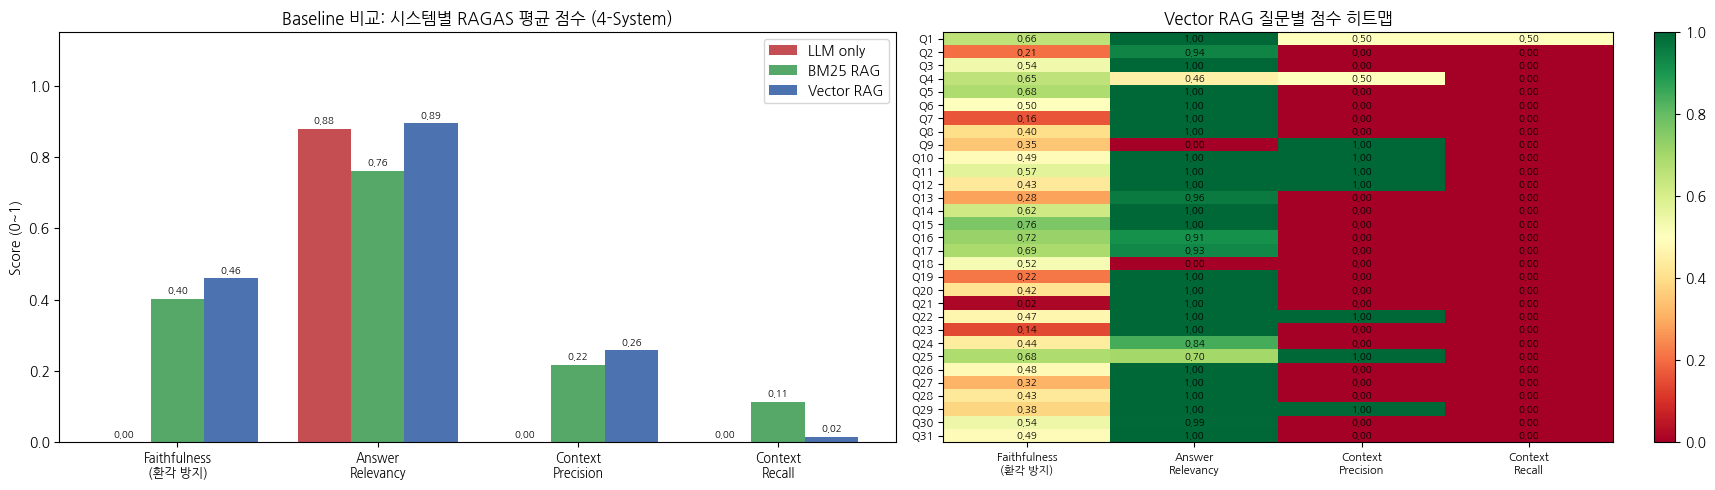

결과 이미지 저장: ragas_evaluation_result.png

===== 4-System Baseline 비교 결과 =====
            faithfulness  answer_relevancy  context_precision  context_recall
system                                                                       
LLM only          0.0000            0.8797             0.0000          0.0000
BM25 RAG          0.4021            0.7621             0.2177          0.1140
Vector RAG        0.4599            0.8947             0.2581          0.0161


In [67]:
import subprocess
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib

# Colab 한글 폰트 설치 (로컬에서는 이미 설치된 경우 무시됨)
subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
fm.fontManager.__init__()  # 폰트 캐시 갱신

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

metric_cols   = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
metric_labels = ["Faithfulness\n(환각 방지)", "Answer\nRelevancy", "Context\nPrecision", "Context\nRecall"]
systems = list(system_results.keys())
colors  = {
    "llm_only"  : "#C44E52",
    "bm25_rag"  : "#55A868",
    "vector_rag": "#4C72B0",
    "model_rag" : "#DD8452",
}
labels  = {
    "llm_only"  : "LLM only",
    "bm25_rag"  : "BM25 RAG",
    "vector_rag": "Vector RAG",
    "model_rag" : "Model RAG",
}

n_sys = len(systems)
x     = range(len(metric_cols))
width = 0.8 / n_sys

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# --- 왼쪽: 시스템별 평균 점수 비교 바 차트 ---
for i, sys in enumerate(systems):
    vals = [system_results[sys][m].mean() for m in metric_cols]
    offset = (i - n_sys / 2 + 0.5) * width
    bars = axes[0].bar(
        [xi + offset for xi in x], vals,
        width=width, label=labels.get(sys, sys), color=colors.get(sys, "#888888")
    )
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                     f"{v:.2f}", ha="center", va="bottom", fontsize=7)

axes[0].set_xticks(list(x))
axes[0].set_xticklabels(metric_labels, fontsize=9)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel("Score (0~1)")
axes[0].set_title("Baseline 비교: 시스템별 RAGAS 평균 점수 (4-System)")
axes[0].legend()

# --- 오른쪽: Vector RAG 질문별 히트맵 ---
heatmap_data = result_df[metric_cols].values
im = axes[1].imshow(heatmap_data, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
axes[1].set_xticks(range(len(metric_cols)))
axes[1].set_xticklabels(metric_labels, fontsize=8)
axes[1].set_yticks(range(len(result_df)))
axes[1].set_yticklabels([f"Q{i+1}" for i in range(len(result_df))], fontsize=8)
axes[1].set_title("Vector RAG 질문별 점수 히트맵")
plt.colorbar(im, ax=axes[1])
for i in range(len(result_df)):
    for j in range(len(metric_cols)):
        axes[1].text(j, i, f"{heatmap_data[i, j]:.2f}",
                     ha="center", va="center", fontsize=7, color="black")

plt.tight_layout()
plt.savefig("ragas_evaluation_result.png", dpi=150, bbox_inches="tight")
plt.show()
print("결과 이미지 저장: ragas_evaluation_result.png")

# --- 요약표: 4 시스템 수치 비교 ---
summary_rows = []
for name, df in system_results.items():
    row = df[metric_cols].mean().round(4).to_dict()
    row["system"] = labels.get(name, name)
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows).set_index("system")
print("\n===== 4-System Baseline 비교 결과 =====")
print(summary_df.to_string())